In [5]:
from sage.all import *
import pickle
import time


def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return (tr,d)

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)[0]
       
        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)
        return results # len(results) = number of distinct Galois orbits of newforms)

N=11
k=4
precision=500
gos=galois_orbit_sum(N,k,precision)
print("len(gos):",len(gos))

for f in gos:
    print("q-expansion:")
    print(f[:20])
    print()

len(gos): 1
q-expansion:
[0, 2, 2, -2, -8, 2, -26, 20, -12, 44, 50, -22, -40, 80, -4, -194, -8, -124, 92, 72]



number of Galois orbits: 1
('j_list', 100)
('j_list', 200)
('j_list', 300)
('j_list', 400)
1 0.0031607866287231444
2 0.004410465558369954
3 0.004663483301798502
4 0.004708003997802734
5 0.004728182156880697
6 0.004752500851949056
7 0.004777765274047852
8 0.004818816979726155
9 0.004883233706156413
10 0.004935236771901449
11 0.004992334047953287
12 0.005074771245320638
13 0.00516048272450765
14 0.005243651072184245
15 0.0053486506144205725
16 0.005470152695973714
17 0.005695867538452149
18 0.00584870179494222
19 0.006160636742909749
20 0.006355182329813639
21 0.00660548210144043
22 0.006824787457784017
23 0.007053804397583008
24 0.007315818468729655
25 0.007913684844970703
26 0.008411769072214763
27 0.008754018942515056
28 0.009165950616200765
29 0.009568881988525391
30 0.010007019837697346
31 0.010690553983052572
32 0.011604634920756023
33 0.012366032600402832
34 0.013050254185994465
35 0.013830836613972981
36 0.014500598112742106
37 0.015431598822275797
38 0.016805068651835123
39 0.01

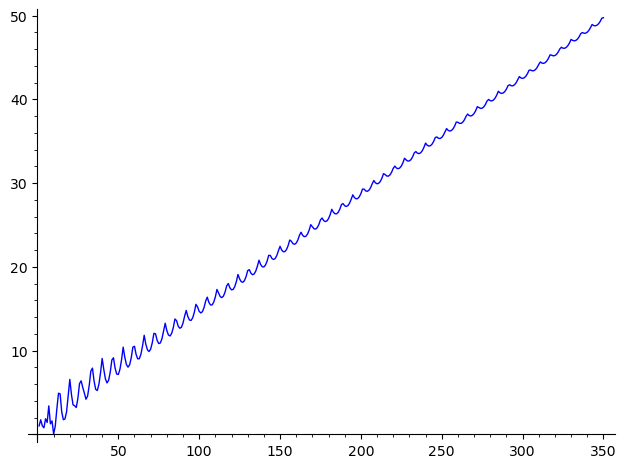

In [10]:
from sage.all import *
import pickle
import time

start=time.time()

def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return (tr,d)

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)[0]
       
        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)
        return results # len(results) = number of distinct Galois orbits of newforms)
N=11
k=4
precision=500 # need a long list to find 350 primes
gos=galois_orbit_sum(N, k, precision)
print("number of Galois orbits:",len(gos))

indexed_list=[(n,gos[0][n]) for n in range(1,len(gos[0]))]#<<<<<<<<<<< drops constant term


h_list=[1]+[pair[1] for pair in indexed_list] # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    if n%100==0: 
        print(("j_list",n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run12april26no11.txt', 'wb') as wfile:
    pickle.dump(gos[0], wfile) 
    
with open('/Users/barrybrent/data2/run12april26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    print(n,(time.time()-start)/60)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run12april26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run12april26no14.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run12april26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped